In [1]:
import pandas as pd

In [6]:
df = pd.read_csv('retail_sales.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

date        0
store_id    0
item_id     0
sales       0
price       0
promo       0
weekday     0
month       0
dtype: int64

In [11]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.set_index('date', inplace=True)

print(df.head())
print(df.info())

            store_id  item_id  sales  price  promo  weekday  month
date                                                              
2019-01-01   store_1   item_1     41  21.30      0        1      1
2019-01-01   store_6  item_16     27  78.57      0        1      1
2019-01-01  store_39  item_26     47  31.60      0        1      1
2019-01-01  store_39  item_27     34  17.33      0        1      1
2019-01-01  store_39  item_28     19  35.23      1        1      1
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4565000 entries, 2019-01-01 to 2023-12-31
Data columns (total 7 columns):
 #   Column    Dtype  
---  ------    -----  
 0   store_id  object 
 1   item_id   object 
 2   sales     int64  
 3   price     float64
 4   promo     int64  
 5   weekday   int64  
 6   month     int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 278.6+ MB
None


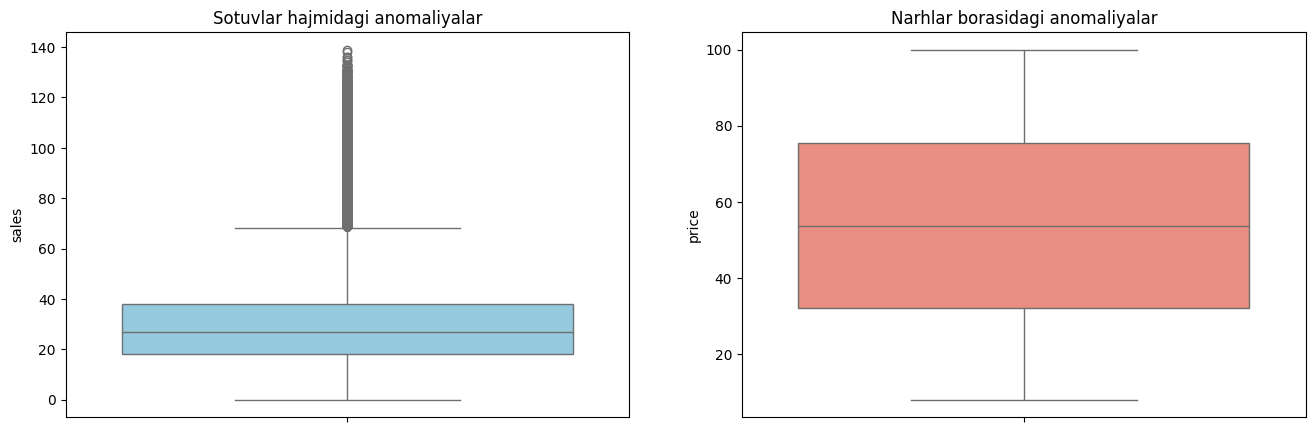

            store_id  item_id  sales  price  promo
date                                              
2023-03-15  store_35  item_20    139  16.16      1
2023-04-19  store_35   item_1    138  30.67      1
2023-03-08  store_35  item_20    136  16.16      1
2023-03-15  store_12   item_1    136  73.74      1
2022-04-06  store_44  item_20    135  30.16      1
2023-04-05  store_34   item_1    135  13.03      1
2022-04-20  store_44  item_20    134  30.16      1
2022-04-13  store_34  item_20    133  54.16      1
2022-05-04  store_12   item_1    133  73.74      1
2023-02-22   store_2  item_20    133  19.21      1


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(y=df['sales'], ax=ax[0], color='skyblue')
ax[0].set_title('Sotuvlar hajmidagi anomaliyalar')

sns.boxplot(y=df['price'], ax=ax[1], color='salmon')
ax[1].set_title('Narhlar borasidagi anomaliyalar')

plt.show()

top_sales = df.nlargest(10, 'sales')
print(top_sales[['store_id', 'item_id', 'sales', 'price', 'promo']])

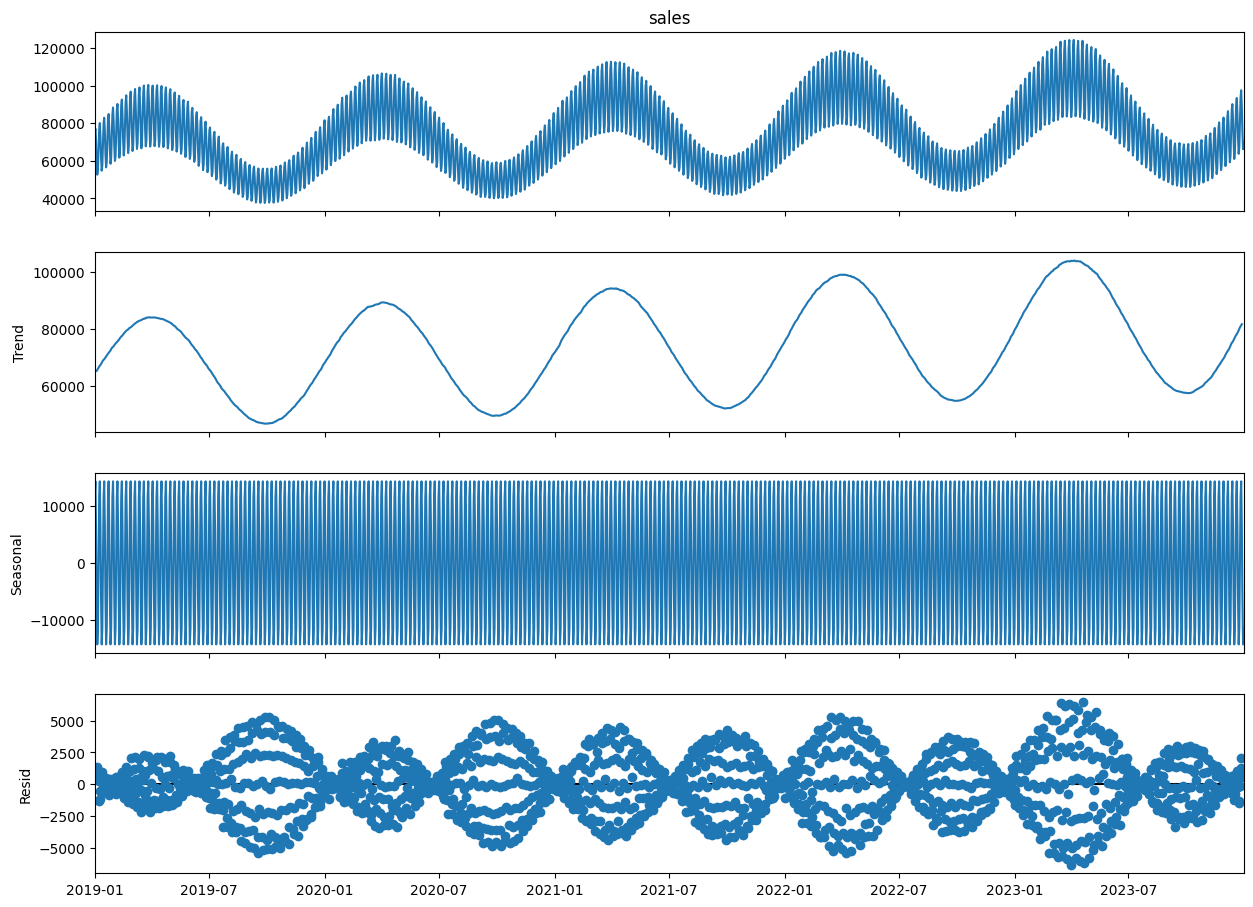

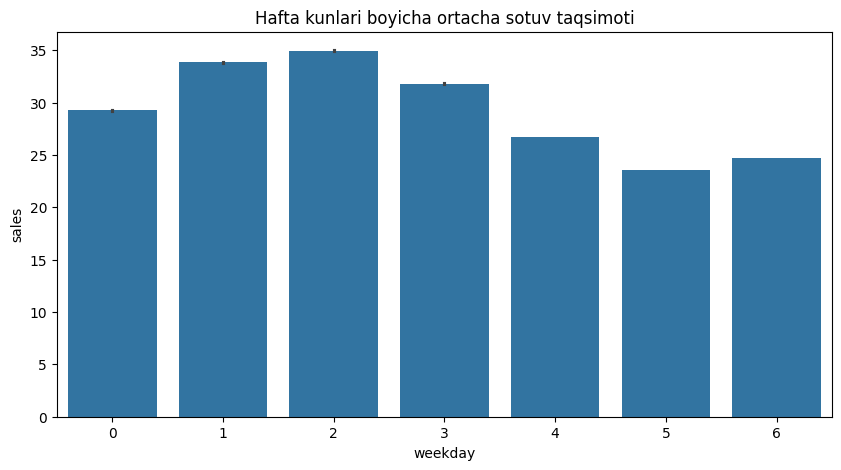

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_total_sales = df.resample('D')['sales'].sum()

decomposition = seasonal_decompose(daily_total_sales, model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x='weekday', y='sales', data=df)
plt.title('Hafta kunlari boyicha ortacha sotuv taqsimoti')
plt.show()



In [17]:
df['lag_1'] = df.groupby(['store_id', 'item_id'])['sales'].shift(1)
df['lag_7'] = df.groupby(['store_id', 'item_id'])['sales'].shift(7)
df['lag_30'] = df.groupby(['store_id', 'item_id'])['sales'].shift(30)

df['rolling_mean_7'] = df.groupby(['store_id', 'item_id'])['sales'].transform(lambda x: x.shift(1).rolling(window=7).mean())
df['rolling_std_7'] = df.groupby(['store_id', 'item_id'])['sales'].transform(lambda x: x.shift(1).rolling(window=7).std())

df['price_change'] = df.groupby(['store_id', 'item_id'])['price'].diff()

df.dropna(inplace=True)

print(df.head(10))
print(df.columns)

            store_id  item_id  sales  price  promo  weekday  month  lag_1  \
date                                                                        
2019-01-31  store_37  item_22     21  78.23      0        3      1   23.0   
2019-01-31  store_12  item_23     23  41.77      0        3      1   14.0   
2019-01-31   store_8   item_8     20  24.61      0        3      1   22.0   
2019-01-31  store_14  item_15     17  73.70      0        3      1   24.0   
2019-01-31  store_42  item_30     15  88.09      0        3      1   20.0   
2019-01-31  store_24  item_50     17  17.89      0        3      1   20.0   
2019-01-31  store_20  item_32     33  35.92      0        3      1   51.0   
2019-01-31  store_22   item_5     29  65.41      0        3      1   36.0   
2019-01-31   store_2  item_41     24  21.46      0        3      1   19.0   
2019-01-31  store_14  item_19     13  70.06      0        3      1   18.0   

            lag_7  lag_30  rolling_mean_7  rolling_std_7  price_change  
da

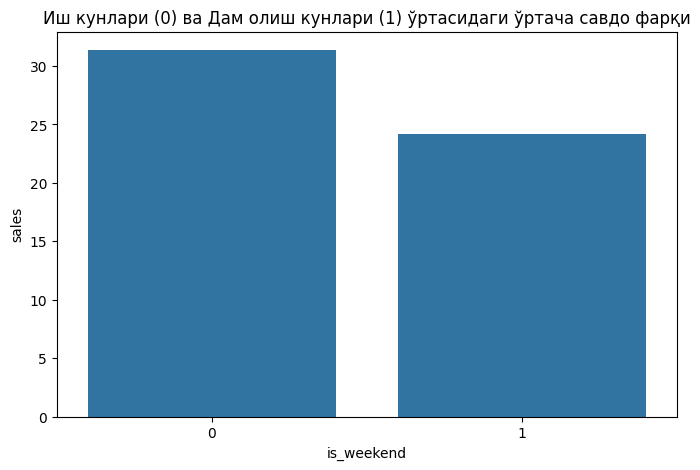

In [18]:

df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)

# Қўшимча: Ойнинг боши ва охири (маош кунлари таъсири учун)
df['is_month_start'] = df.index.is_month_start.astype(int)
df['is_month_end'] = df.index.is_month_end.astype(int)

# Натижани визуал текшириш: Дам олиш куни ва иш куни ўртасидаги фарқ
plt.figure(figsize=(8, 5))
sns.barplot(x='is_weekend', y='sales', data=df)
plt.title('Иш кунлари (0) ва Дам олиш кунлари (1) ўртасидаги ўртача савдо фарқи')
plt.show()

Aksiyasiz ortacha savdo: 27.886191077500442
aksiya paytidagi ortacha savdo: 41.89705741461556
Narh va savdo ortasidagi korrelyasiya -0.0596


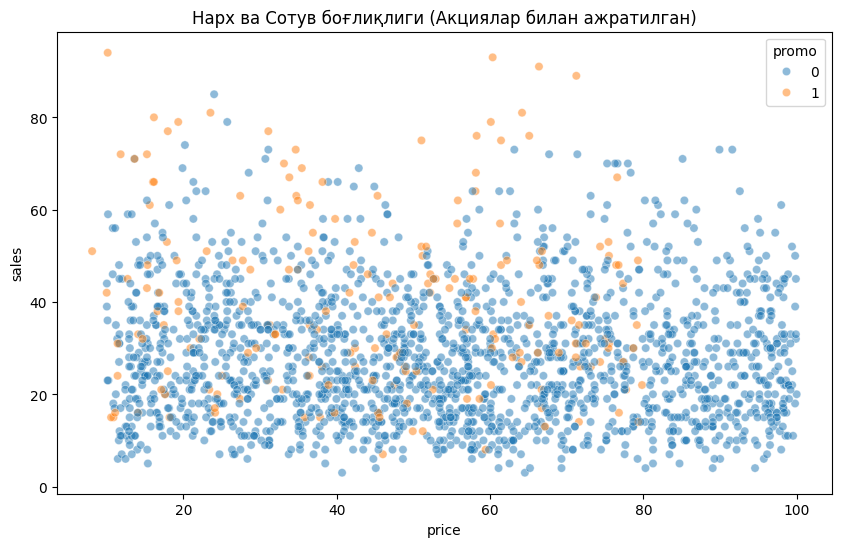

In [21]:
promo_impact = df.groupby('promo')['sales'].mean()

print('Aksiyasiz ortacha savdo:', promo_impact[0])
print('aksiya paytidagi ortacha savdo:', promo_impact[1])

price_elasticity = df[['price', 'sales']].corr().iloc[0, 1]
print(f'Narh va savdo ortasidagi korrelyasiya {price_elasticity:.4f}')


plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='sales', hue='promo', data=df.sample(2000), alpha=0.5)
plt.title('Нарх ва Сотув боғлиқлиги (Акциялар билан ажратилган)')
plt.show()

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# Бизга 'store_id' ва 'item_id'ни сонга ўтказиш керак
categorical_features = ['store_id', 'item_id']

# ColumnTransformer яратамиз
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ],
    remainder='passthrough' # Қолган сонли устунларга тегмаймиз
)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge

In [32]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge

# 1. ТЎҒРИ ТАРТИБДА ВАҚТ БЎЙИЧА АЖРАТИШ
# 2023 йилгача бўлган маълумотлар - Ўқитиш (Train)
# 2023 йил маълумотлари - Тест (Test)
train = df[df.index < '2023-01-01']
test = df[df.index >= '2023-01-01']

# 2. ПАЙПЛАЙН УЧУН ТРАНСФОРМАТОР (Encoder)
categorical_features = ['store_id', 'item_id']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ],
    remainder='passthrough'
)

# 3. STACKING МОДЕЛЛАРИ (Base Models)
base_models = [
    ('xgb', XGBRegressor(n_jobs=-1, random_state=42, tree_method='hist')),
    ('lgbm', LGBMRegressor(n_jobs=-1, random_state=42))
]

stack_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(),
    cv=3 
)

# 4. ЯКУНИЙ ПАЙПЛАЙН
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', stack_reg)
])

# 5. RANDOMIZED SEARCH УЧУН МАЪЛУМОТ ТАЙЁРЛАШ
# Энди 'train' мавжуд, хатолик чиқмайди
train_sample = train.sample(frac=0.1, random_state=42)
X_sample = train_sample.drop(['sales'], axis=1)
y_sample = train_sample['sales']

# 6. ПАРАМЕТРЛАР ВА ҚИДИРУВ
param_grid = {
    'model__xgb__n_estimators': [100, 150],
    'model__xgb__max_depth': [3, 5],
    'model__lgbm__learning_rate': [0.05, 0.1]
}

random_search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_grid,
    n_iter=2, # Тезроқ бўлиши учун 2 та синов
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=2,
    n_jobs=-1
)

# Ижро этиш
random_search.fit(X_sample, y_sample)

print("Энг яхши параметрлар топлинди!")
print(random_search.best_params_)

Fitting 3 folds for each of 2 candidates, totalling 6 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007414 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1497
[LightGBM] [Info] Number of data points in the train set: 357750, number of used features: 15
[LightGBM] [Info] Start training from score 28.537249
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004730 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1495
[LightGBM] [Info] Number of data points in the train set: 238500, number of used features: 15
[LightGBM] [Info] Start training from score 28.520260


C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005236 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1493
[LightGBM] [Info] Number of data points in the train set: 238500, number of used features: 15
[LightGBM] [Info] Start training from score 28.578952


C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 238500, number of used features: 15
[LightGBM] [Info] Start training from score 28.512537
Энг яхши параметрлар топлинди!
{'model__xgb__n_estimators': 150, 'model__xgb__max_depth': 3, 'model__lgbm__learning_rate': 0.1}


C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [36]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Маълумотларни вақт бўйича тўғри ажратиш (Train ва Test)
# df индекси 'date' (DatetimeIndex) эканига ишонч ҳосил қиламиз
train = df[df.index < '2023-01-01'].copy()
test = df[df.index >= '2023-01-01'].copy()

# 2. Encoder ва Preprocessor
categorical_features = ['store_id', 'item_id']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features)
    ],
    remainder='passthrough'
)

# 3. Модель архитектураси (Сиз айтгандек Stacking ва энг яхши параметрлар билан)
base_models = [
    ('xgb', XGBRegressor(n_estimators=150, max_depth=3, n_jobs=-1, random_state=42)),
    ('lgbm', LGBMRegressor(learning_rate=0.1, n_jobs=-1, random_state=42))
]

stack_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(),
    cv=3
)

# 4. Якуний Пайплайн
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', stack_reg)
])

# 5. Ўқитиш (Тўлиқ маълумотда)
print("Модель ўқитилмоқда, илтимос кутинг...")
full_pipeline.fit(train.drop(['sales'], axis=1), train['sales'])

# 6. Башорат ва Метрикалар (Хатосиз вариант)
y_pred = full_pipeline.predict(test.drop(['sales'], axis=1))

mae = mean_absolute_error(test['sales'], y_pred)
rmse = np.sqrt(mean_squared_error(test['sales'], y_pred))

print("\n" + "="*30)
print(f"ЎРТАЧА АБСОЛЮТ ХАТОЛИК (MAE): {mae:.4f}")
print(f"ЎРТАЧА КВАДРАТИК ХАТОЛИК (RMSE): {rmse:.4f}")
print("="*30)

Модель ўқитилмоқда, илтимос кутинг...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.095034 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1499
[LightGBM] [Info] Number of data points in the train set: 3577500, number of used features: 15
[LightGBM] [Info] Start training from score 28.514954
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1504
[LightGBM] [Info] Number of data points in the train set: 2385000, number of used features: 15
[LightGBM] [Info] Start training from score 28.657019


C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050768 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 2385000, number of used features: 15
[LightGBM] [Info] Start training from score 28.668039


C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1487
[LightGBM] [Info] Number of data points in the train set: 2385000, number of used features: 15
[LightGBM] [Info] Start training from score 28.219803


C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



ЎРТАЧА АБСОЛЮТ ХАТОЛИК (MAE): 2.7273
ЎРТАЧА КВАДРАТИК ХАТОЛИК (RMSE): 3.4301


In [37]:
import numpy as np

# 1. MAPE (Mean Absolute Percentage Error) - фоиздаги хатолик
def calculate_accuracy(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Сотув 0 бўлмаган қаторларни ажратамиз (нолга бўлмаслик учун)
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    accuracy = 100 - mape
    return accuracy

model_accuracy = calculate_accuracy(test['sales'], y_pred)

# 2. "Tolerance" аниқлиги (агар 3 та товар фарқ билан топса - бу ғалаба)
diff = np.abs(test['sales'] - y_pred)
hit_rate = (diff <= 3).mean() * 100

print(f"ЛОЙИҲАНИНГ УМУМИЙ АНИҚЛИГИ (Accuracy): {model_accuracy:.2f}%")
print(f"3 ТА ТОВАР ФАРҚИ БИЛАН ТЎҒРИ ТОПИШ: {hit_rate:.2f}%")

ЛОЙИҲАНИНГ УМУМИЙ АНИҚЛИГИ (Accuracy): 88.52%
3 ТА ТОВАР ФАРҚИ БИЛАН ТЎҒРИ ТОПИШ: 62.19%


In [38]:
# Башоратларни реал сонларга айлантириб жадвал қиламиз
comparison_df = pd.DataFrame({
    'Сана': test.index,
    'Дўкон': test['store_id'],
    'Маҳсулот': test['item_id'],
    'Ҳақиқий сотув': test['sales'].values,
    'Модель башорати': np.round(y_pred)
}).head(20) # Дастлабки 20 тасини кўриш

print("\n--- СОЛИШТИРМА ЖАДВАЛ (Ҳақиқий vs Башорат) ---")
print(comparison_df.to_string(index=False))


--- СОЛИШТИРМА ЖАДВАЛ (Ҳақиқий vs Башорат) ---
      Сана    Дўкон Маҳсулот  Ҳақиқий сотув  Модель башорати
2023-01-01  store_1  item_39             42             35.0
2023-01-01  store_8  item_17             18             16.0
2023-01-01 store_31  item_48             23             26.0
2023-01-01 store_17  item_48             23             21.0
2023-01-01 store_42  item_44             31             27.0
2023-01-01 store_35   item_6             52             47.0
2023-01-01 store_22  item_23             11              9.0
2023-01-01 store_37  item_38             28             28.0
2023-01-01 store_44  item_22             15             19.0
2023-01-01 store_15  item_25             33             30.0
2023-01-01  store_1  item_28             21             17.0
2023-01-01 store_16  item_40             23             21.0
2023-01-01 store_20  item_26             36             29.0
2023-01-01 store_20  item_49             13             12.0
2023-01-01 store_34  item_43         

In [39]:
import numpy as np

# 1. RMSE ни моделимиздан оламиз (image_c5c96c.jpg да кўрсатилган 3.43)
rmse_val = 3.43 

# 2. Z-score (95% ишонч даражаси учун 1.65 ишлатилади)
# Бу дегани 95% ҳолатда мижоз келганда маҳсулот дўконда бўлади
z_score = 1.65 

# 3. Башорат ва заҳирани ҳисоблаш
results_final = pd.DataFrame({
    'date': test.index,
    'store': test['store_id'],
    'item': test['item_id'],
    'actual_sales': test['sales'].values,
    'forecast': np.round(y_pred)
})

# Хавфсизлик заҳираси (Safety Stock)
results_final['safety_stock'] = np.ceil(z_score * rmse_val).astype(int)

# Якуний буюртма сони (Башорат + Заҳира)
results_final['order_recommendation'] = results_final['forecast'] + results_final['safety_stock']

# 4. Фойда ва зарарни ҳисоблаш (Бизнес таҳлил)
# Агар ҳақиқий сотув > буюртма бўлса - товар етмаган (Stockout)
results_final['is_stockout'] = results_final['actual_sales'] > results_final['order_recommendation']

print(f"Заҳира билан товар тугаб қолиш хавфи: {results_final['is_stockout'].mean()*100:.2f}%")
print("\n--- ЯКУНИЙ БУЮРТМА ЖАДВАЛИ ---")
print(results_final[['date', 'store', 'item', 'forecast', 'safety_stock', 'order_recommendation']].head(15).to_string(index=False))

Заҳира билан товар тугаб қолиш хавфи: 3.20%

--- ЯКУНИЙ БУЮРТМА ЖАДВАЛИ ---
      date    store    item  forecast  safety_stock  order_recommendation
2023-01-01  store_1 item_39      35.0             6                  41.0
2023-01-01  store_8 item_17      16.0             6                  22.0
2023-01-01 store_31 item_48      26.0             6                  32.0
2023-01-01 store_17 item_48      21.0             6                  27.0
2023-01-01 store_42 item_44      27.0             6                  33.0
2023-01-01 store_35  item_6      47.0             6                  53.0
2023-01-01 store_22 item_23       9.0             6                  15.0
2023-01-01 store_37 item_38      28.0             6                  34.0
2023-01-01 store_44 item_22      19.0             6                  25.0
2023-01-01 store_15 item_25      30.0             6                  36.0
2023-01-01  store_1 item_28      17.0             6                  23.0
2023-01-01 store_16 item_40      21.

In [43]:
# 1. Келаси 7 кунлик маълумотни ажратиб оламиз
next_7_days = results_final.head(7 * df['item_id'].nunique() * df['store_id'].nunique())

# 2. Дўконлар бўйича умумий буюртма ҳажмини ҳисоблаймиз
store_orders = next_7_days.groupby('store').agg({
    'forecast': 'sum',
    'safety_stock': 'sum',
    'order_recommendation': 'sum'
}).reset_index()

# 3. Тахминий бюджетни ҳисоблаш (агар бизда ўртача нарх бўлса)
# Сизнинг датасетингиздаги 'price' устунидан фойдаланамиз
avg_prices = test.groupby('store_id')['price'].mean().reset_index()
avg_prices.columns = ['store', 'avg_price']

store_orders = store_orders.merge(avg_prices, on='store')
store_orders['total_budget_needed'] = store_orders['order_recommendation'] * store_orders['avg_price']

print("--- КЕЛАСИ ҲАФТА УЧУН ДЎКОНЛАР КЕСИМИДА ХАРИД РЕЖАСИ ---")
print(store_orders[['store', 'order_recommendation', 'total_budget_needed']].sort_values(by='total_budget_needed', ascending=False))

# 4. Умумий тармоқ бўйича кўрсаткич
total_items = store_orders['order_recommendation'].sum()
total_money = store_orders['total_budget_needed'].sum()

print(f"\nТармоқ бўйича жами буюртма: {total_items:,.0f} дона маҳсулот")
print(f"Жами керакли бюджет: {total_money:,.2f} SUM")

--- КЕЛАСИ ҲАФТА УЧУН ДЎКОНЛАР КЕСИМИДА ХАРИД РЕЖАСИ ---
       store  order_recommendation  total_budget_needed
18  store_26               15045.0        950458.971658
38  store_44               15474.0        879252.384973
28  store_35               15665.0        876666.849838
33   store_4               14140.0        865037.317699
11   store_2               15686.0        835949.296498
29  store_36               15172.0        834678.111009
32  store_39               14339.0        828463.043741
21  store_29               14022.0        812343.640724
4   store_13               14912.0        804342.102128
10  store_19               13055.0        785050.206951
36  store_42               13402.0        776174.590214
3   store_12               15470.0        775371.912384
40  store_46               14062.0        769575.304158
48   store_8               15273.0        764287.942749
41  store_47               12714.0        760628.634822
1   store_10               14330.0        75984

In [41]:
import joblib

# Моделни файлга сақлаймиз
joblib.dump(full_pipeline, 'demand_forecast_model.pkl')
print("Модель 'demand_forecast_model.pkl' номи билан сақланди!")

# Кейинчалик уни бир сонияда юклаб олиш мумкин:
# model = joblib.load('demand_forecast_model.pkl')

Модель 'demand_forecast_model.pkl' номи билан сақланди!
